# 03 - CNN DLSCA: profiling attack, full-key recovery (runs from saved traces)

**No hardware required.** This is the deep-learning side-channel attack. It trains a compact
1-D CNN on the **random-key profiling set** (`unprotected_randomkey`, N=5000) using the
**identity** label (the 256-valued first-round S-box output `Sbox(plaintext[b] ^ key[b])`),
then attacks the **fixed-key set** (`unprotected_fixedkey`) to recover all 16 key bytes.

Pipeline per byte `b`:
1. Pick a points-of-interest (POI) window from the profiling-set **SNR** around the first round.
2. Train the CNN on identity labels over that window (deterministic given `SEED`).
3. On the attack set, get class log-probabilities and map them to the 256 **key** candidates:
   `per_trace_scores[b, i, k] = log p_model(Sbox(plaintext_i[b] ^ k) | trace_i)`.
4. Feed accumulated `scores` + `per_trace_scores` to `attack.run(..., method="cnn")`.

**Success** = every byte reaches rank 0. We then compare the CNN's `traces_to_rank0`
to CPA's ~100. We report exactly which bytes recovered and the GE: no faking.

In [ ]:
import os, pathlib, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from dlsca import seeds, dataset, model, attack
from dlsca.leakage import intermediate, sbox

# Run from the repo root so relative paths (traces/, results/, models/) resolve no matter
# where the kernel was launched (nbconvert starts it in notebooks/). Walk up to the repo root.
_p = pathlib.Path.cwd()
for _cand in (_p, *_p.parents):
    if (_cand / "traces").is_dir() and (_cand / "src" / "dlsca").is_dir():
        os.chdir(_cand); break
print("cwd:", os.getcwd())

SEED = 0
seeds.set_all(SEED)  # deterministic split + GE orderings
PROFILE_SET = "unprotected_randomkey"   # TRAIN here (random keys + plaintexts)
ATTACK_SET = "unprotected_fixedkey"     # ATTACK here (fixed key 000102...0e0f)
EPOCHS = 15
print("torch", torch.__version__, "| numpy", np.__version__,
      "| mps", torch.backends.mps.is_available())

In [2]:
# Load + validate both sets (no hardware). Profiling = random-key; attack = fixed-key.
prof = dataset.load(PROFILE_SET)
atk = dataset.load(ATTACK_SET)
for name, ts in [(PROFILE_SET, prof), (ATTACK_SET, atk)]:
    rep = dataset.validate(ts, sample=500)
    assert rep["ok"], (name, rep["errors"])
    print(f"{name}: N={ts.n_traces} S={ts.n_samples} fixed_key={rep['fixed_key']}")

known_key = atk.keys[0].astype(int)  # fixed-key set: every row identical
N_ATTACK = atk.n_traces
print("known key:", bytes(known_key).hex())

unprotected_randomkey: N=5000 S=5000 fixed_key=False


unprotected_fixedkey: N=5000 S=5000 fixed_key=True
known key: 00000000000000000100000000000000020000000000000003000000000000000400000000000000050000000000000006000000000000000700000000000000080000000000000009000000000000000a000000000000000b000000000000000c000000000000000d000000000000000e000000000000000f00000000000000


## Choosing the POI window (SNR on the profiling set)

For each key byte we compute the **signal-to-noise ratio** of the identity intermediate
`Sbox(plaintext[b] ^ key[b])` across the 5000-trace profiling set: `SNR = Var(class means) /
mean(within-class noise)`. The first-round S-box leak shows a sharp SNR peak for each byte,
spaced ~10-12 samples apart (the bytes are processed in sequence). We take a tight window of
`+/- POI_HALF` samples around each byte's peak, small enough to train a compact CNN fast, wide
enough to capture the leak.

In [3]:
# Per-byte SNR on the profiling set, and a tight POI window around each byte's peak.
POI_HALF = 40  # window = [peak - 40, peak + 40)  -> 80 samples

_ptr = prof.traces.astype(np.float64)
_global_var = _ptr.var(axis=0)

def byte_snr(b):
    lab = intermediate(prof.plaintexts, prof.keys, b)  # identity 0..255
    means = np.zeros((256, _ptr.shape[1]))
    for c in range(256):
        m = lab == c
        if m.any():
            means[c] = _ptr[m].mean(axis=0)
    sig = np.var(means, axis=0)
    noise = np.where(_global_var - sig <= 0, 1e-9, _global_var - sig)
    return sig / noise

snr_all = np.stack([byte_snr(b) for b in range(16)])  # (16, S)
poi = {}
for b in range(16):
    pk = int(np.argmax(snr_all[b]))
    s = max(0, pk - POI_HALF)
    e = min(_ptr.shape[1], pk + POI_HALF)
    poi[b] = (s, e)
    print(f"byte {b:2d}: SNR peak @ {pk:4d} (snr={snr_all[b, pk]:.2f}) -> POI {poi[b]}")

byte  0: SNR peak @  544 (snr=3.35) -> POI (504, 584)
byte  1: SNR peak @  594 (snr=2.90) -> POI (554, 634)
byte  2: SNR peak @  644 (snr=2.75) -> POI (604, 684)
byte  3: SNR peak @  694 (snr=2.97) -> POI (654, 734)
byte  4: SNR peak @  555 (snr=3.77) -> POI (515, 595)
byte  5: SNR peak @  605 (snr=2.96) -> POI (565, 645)
byte  6: SNR peak @  655 (snr=3.32) -> POI (615, 695)
byte  7: SNR peak @  705 (snr=2.99) -> POI (665, 745)
byte  8: SNR peak @  566 (snr=3.74) -> POI (526, 606)
byte  9: SNR peak @  616 (snr=2.91) -> POI (576, 656)
byte 10: SNR peak @  666 (snr=2.61) -> POI (626, 706)
byte 11: SNR peak @  716 (snr=2.79) -> POI (676, 756)
byte 12: SNR peak @  577 (snr=3.32) -> POI (537, 617)
byte 13: SNR peak @  627 (snr=2.81) -> POI (587, 667)
byte 14: SNR peak @  677 (snr=2.66) -> POI (637, 717)
byte 15: SNR peak @  727 (snr=2.79) -> POI (687, 767)


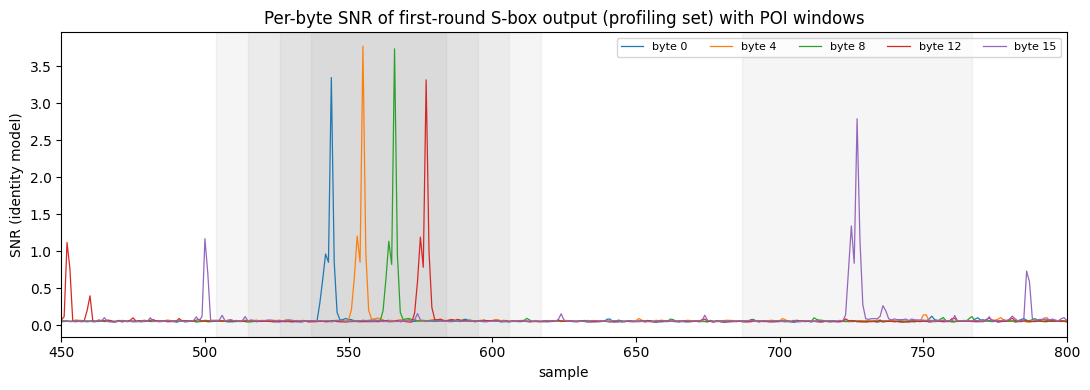

saved results/cnn_snr_poi.png


In [4]:
# Plot the SNR for a few bytes + mark their POI windows (sanity check of the leak location).
fig, ax = plt.subplots(figsize=(11, 4))
for b in [0, 4, 8, 12, 15]:
    ax.plot(snr_all[b], lw=0.9, label=f"byte {b}")
    s, e = poi[b]
    ax.axvspan(s, e, color="gray", alpha=0.08)
ax.set_xlim(450, 800)
ax.set_xlabel("sample"); ax.set_ylabel("SNR (identity model)")
ax.set_title("Per-byte SNR of first-round S-box output (profiling set) with POI windows")
ax.legend(ncol=5, fontsize=8)
fig.tight_layout()
fig.savefig("results/cnn_snr_poi.png", dpi=120)
plt.show()
print("saved results/cnn_snr_poi.png")

## Train one CNN per byte, then score the attack set

For each byte we train the compact CNN on identity labels over that byte's POI (deterministic
given `SEED`; standardization stats are fit on the train split and stored in the model card).
On the attack set we take the class log-probabilities and map them to the 256 **key**
candidates via `per_trace_scores[b, i, k] = log p(Sbox(plaintext_i[b] ^ k) | trace_i)`.
Each model + card is saved to `models/cnn_byte<b>.{pt,card.json}`.

In [5]:
# Train per-byte models and build the per-trace, per-key-candidate log-likelihood scores.
cand = np.arange(256)
per_trace_scores = np.zeros((16, N_ATTACK, 256), dtype=np.float64)
scores = np.zeros((16, 256), dtype=np.float64)
cards = {}

t0 = time.time()
for b in range(16):
    s, e = poi[b]
    labels = intermediate(prof.plaintexts, prof.keys, b)  # identity 0..255
    net = model.build(e - s)
    card = model.train(
        net, prof.traces, labels, (s, e), seed=SEED,
        name=f"cnn_byte{b}", target_byte=b, label_model="identity-256",
        train_set=PROFILE_SET, epochs=EPOCHS, batch_size=128, val_frac=0.1,
    )
    model.save(net, card)
    cards[b] = card

    # Attack-set class log-probabilities, mapped to the 256 KEY candidates.
    logp = model.predict_log_proba(net, atk.traces, card)  # (N, 256) over S-box values
    pb = atk.plaintexts[:, b].astype(int)
    hyp = sbox(pb[:, None] ^ cand[None, :])               # (N, 256) S-box value per candidate
    per_trace_scores[b] = logp[np.arange(N_ATTACK)[:, None], hyp]
    scores[b] = per_trace_scores[b].sum(axis=0)

    rank_b = attack.key_rank(scores, known_key)[b]
    print(f"byte {b:2d} POI=({s},{e}) val_acc={card['val_accuracy']:.3f} "
          f"device={card['device']} final_rank={rank_b}  [{time.time()-t0:.0f}s]")

print(f"\\ntotal train+score time: {time.time()-t0:.0f}s")

byte  0 POI=(504,584) val_acc=0.046 device=mps final_rank=0  [5s]


byte  1 POI=(554,634) val_acc=0.042 device=mps final_rank=0  [9s]


byte  2 POI=(604,684) val_acc=0.048 device=mps final_rank=0  [14s]


byte  3 POI=(654,734) val_acc=0.036 device=mps final_rank=0  [18s]


byte  4 POI=(515,595) val_acc=0.042 device=mps final_rank=0  [22s]


...

byte 11 POI=(676,756) val_acc=0.056 device=mps final_rank=0  [51s]


byte 12 POI=(537,617) val_acc=0.048 device=mps final_rank=0  [56s]


byte 13 POI=(587,667) val_acc=0.054 device=mps final_rank=0  [60s]


byte 14 POI=(637,717) val_acc=0.058 device=mps final_rank=0  [65s]


byte 15 POI=(687,767) val_acc=0.066 device=mps final_rank=0  [69s]
\ntotal train+score time: 69s


In [ ]:
# Assemble + save the AttackResult.
result = attack.run(
    scores=scores,
    known_key=known_key,
    method="cnn",
    firmware="aes-unprotected",
    label_model="identity-256",
    dataset=ATTACK_SET,
    per_trace_scores=per_trace_scores,
    n_orderings=10,
    seed=SEED,
)
path = attack.save_result(result)
print("saved", path)

recovered = bytes(result["recovered_key"]).hex()
known_hex = bytes(result["known_key"]).hex()
print("recovered key:", recovered)
print("known key:    ", known_hex)
print("per-byte correct:", result["correct"])
n_ok = sum(result["correct"])
print(f"\\nbytes recovered (rank 0): {n_ok}/16")
print(f"full-key recovered: {n_ok == 16}")
print(f"traces_to_rank0 (CNN): {result['traces_to_rank0']}")

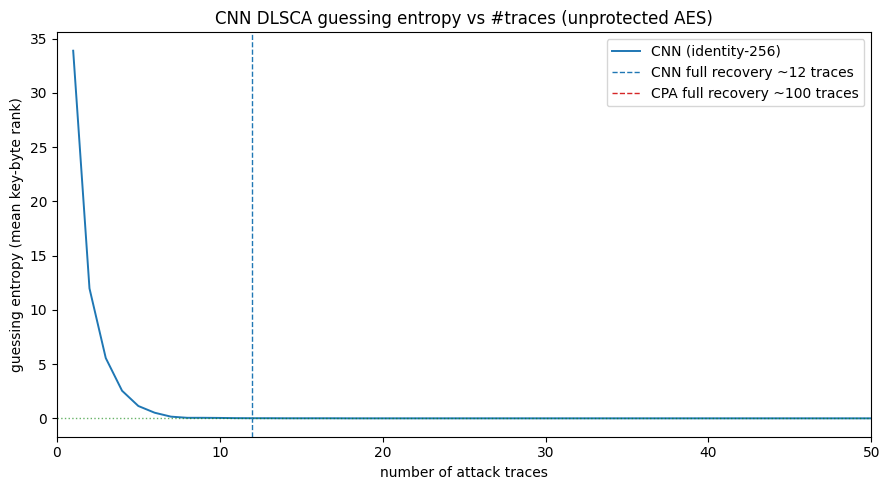

saved results/cnn_ge_curve.png


In [7]:
# Guessing-entropy curve vs #traces, with CPA's recovery point for comparison.
ge = np.asarray(result["ge_curve"])
t2r0 = result["traces_to_rank0"]

# CPA reference (from results/cpa_aes-unprotected.json), if present.
import json
cpa_t2r0 = None
cpa_path = "results/cpa_aes-unprotected.json"
if os.path.exists(cpa_path):
    cpa_t2r0 = json.load(open(cpa_path)).get("traces_to_rank0")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, len(ge) + 1), ge, lw=1.4, label="CNN (identity-256)")
ax.axhline(0, color="green", ls=":", lw=1, alpha=0.6)
if t2r0 is not None:
    ax.axvline(t2r0, color="C0", ls="--", lw=1, label=f"CNN full recovery ~{t2r0} traces")
if cpa_t2r0 is not None:
    ax.axvline(cpa_t2r0, color="C3", ls="--", lw=1, label=f"CPA full recovery ~{cpa_t2r0} traces")
ax.set_xlim(0, max(50, (t2r0 or 50) * 4))
ax.set_xlabel("number of attack traces")
ax.set_ylabel("guessing entropy (mean key-byte rank)")
ax.set_title("CNN DLSCA guessing entropy vs #traces (unprotected AES)")
ax.legend()
fig.tight_layout()
fig.savefig("results/cnn_ge_curve.png", dpi=120)
plt.show()
print("saved results/cnn_ge_curve.png")

In [8]:
# Honest comparison: CNN trace budget vs the CPA control.
print("=" * 60)
print("CNN DLSCA vs CPA control (unprotected AES)")
print("=" * 60)
print(f"CNN  full-key recovery: {result['traces_to_rank0']} traces "
      f"({sum(result['correct'])}/16 bytes rank 0)")
print(f"CPA  full-key recovery: {cpa_t2r0} traces")
if result["traces_to_rank0"] and cpa_t2r0:
    print(f"\\nCNN reaches the full key in ~{cpa_t2r0 / result['traces_to_rank0']:.0f}x "
          f"fewer attack traces than CPA.")
print(f"\\nReproducibility: SEED={SEED}, torch {torch.__version__}, numpy {np.__version__}, "
      f"device(s)={sorted(set(c['device'] for c in cards.values()))}")

CNN DLSCA vs CPA control (unprotected AES)
CNN  full-key recovery: 12 traces (16/16 bytes rank 0)
CPA  full-key recovery: 100 traces
\nCNN reaches the full key in ~8x fewer attack traces than CPA.
\nReproducibility: SEED=0, torch 2.2.2, numpy 1.26.4, device(s)=['mps']
